# Brachistochrone GKP State Preparation

This notebook constructs the time-optimal (quantum brachistochrone) Hamiltonian that drives the vacuum to each of the six cardinal GKP logical states, following Carlini et al., *Phys. Rev. Lett.* **96**, 060503 (2006). For each target we evolve under the optimal $H$ for the minimum time $T = \Omega_B / \lVert H \rVert$ set by the Mandelstam-Tamm bound, and animate the Wigner function along the trajectory. These Hamiltonians serve as a lower-bound benchmark against which realistic control schemes (bounded drive, finite bandwidth, experimental operators) can be compared.


## Imports


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from gkp_optimal_control.animation import animate_wigner
from gkp_optimal_control.brachistochrone import quantum_brachistochrone_hamiltonian
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import wigner_trajectory

set_plot_style()

## System parameters

Square-lattice GKP code with lattice spacings $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$, envelope width $\Delta$, and spectral-norm bound $\lVert H \rVert = \omega$ on the driving Hamiltonian. The six cardinal logical states are built from $\ket{0_L}, \ket{1_L}$ by the standard Bloch-sphere combinations.


In [2]:
n_fock = 80
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi / 2) * 1j

energy_bound = 1.0

vac = qt.basis(n_fock, 0)

gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
gkp_x_plus = (gkp_0 + gkp_1).unit()
gkp_x_minus = (gkp_0 - gkp_1).unit()
gkp_y_plus = (gkp_0 + 1j * gkp_1).unit()
gkp_y_minus = (gkp_0 - 1j * gkp_1).unit()

targets = {
    r"0_L": gkp_0,
    r"1_L": gkp_1,
    r"+_L": gkp_x_plus,
    r"-_L": gkp_x_minus,
    r"+i_L": gkp_y_plus,
    r"-i_L": gkp_y_minus,
}

gkp_squeezing_db = -10 * np.log10(gkp_delta**2)
print(f"Effective GKP squeezing: {gkp_squeezing_db:.2f} dB")

Effective GKP squeezing: 10.46 dB


## Time-optimal Hamiltonians and Wigner trajectories

For each target $\ket{\psi_f}$, `quantum_brachistochrone_hamiltonian` returns the constant Hamiltonian acting in the 2D subspace spanned by $\ket{0}$ and the component of $\ket{\psi_f}$ orthogonal to it, together with the minimum evolution time $T = \Omega_B / \lVert H \rVert$ where $\Omega_B = \arccos|\braket{0|\psi_f}|$ is the Bures angle. We integrate with `qt.sesolve` (the dynamics are unitary; no collapse operators) and animate each Wigner trajectory to `../vids/brachistochrone/`.


In [3]:
n_steps = 200
x_bound = 5.0
y_bound = 5.0
grid_points = 200

trajectories = {}
optimal_hamiltonians = {}
min_times = {}

for label, final_state in targets.items():
    print(f"Preparing |{label}>...")
    h_optimal, min_time = quantum_brachistochrone_hamiltonian(
        vac, final_state, energy_bound=energy_bound
    )
    tlist = np.linspace(0.0, min_time, n_steps)
    result = qt.sesolve(h_optimal, vac, tlist)

    optimal_hamiltonians[label] = h_optimal
    min_times[label] = min_time
    trajectories[label] = (tlist, result)

    xvec, yvec, wigner_states = wigner_trajectory(
        result, x_bound, y_bound, grid_points=grid_points
    )
    animate_wigner(
        wigner_states,
        xvec,
        yvec,
        title=rf"$\ket{{{label}}}$",
        save_path=f"../../vids/brachistochrone/vac_to_gkp_{label}.mp4",
        dpi=300,
    )
    print(f"    min_time = {min_time:.4f}")

Preparing |0_L>...
    min_time = 0.9953
Preparing |1_L>...
    min_time = 1.3471
Preparing |+_L>...
    min_time = 0.9984
Preparing |-_L>...
    min_time = 1.3408
Preparing |+i_L>...
    min_time = 1.1422
Preparing |-i_L>...
    min_time = 1.1422


## Final-state Wigner distributions

Sanity check: after evolving for exactly $T$, each target should be reached up to a global phase. We plot the Wigner function of the last state in each trajectory.


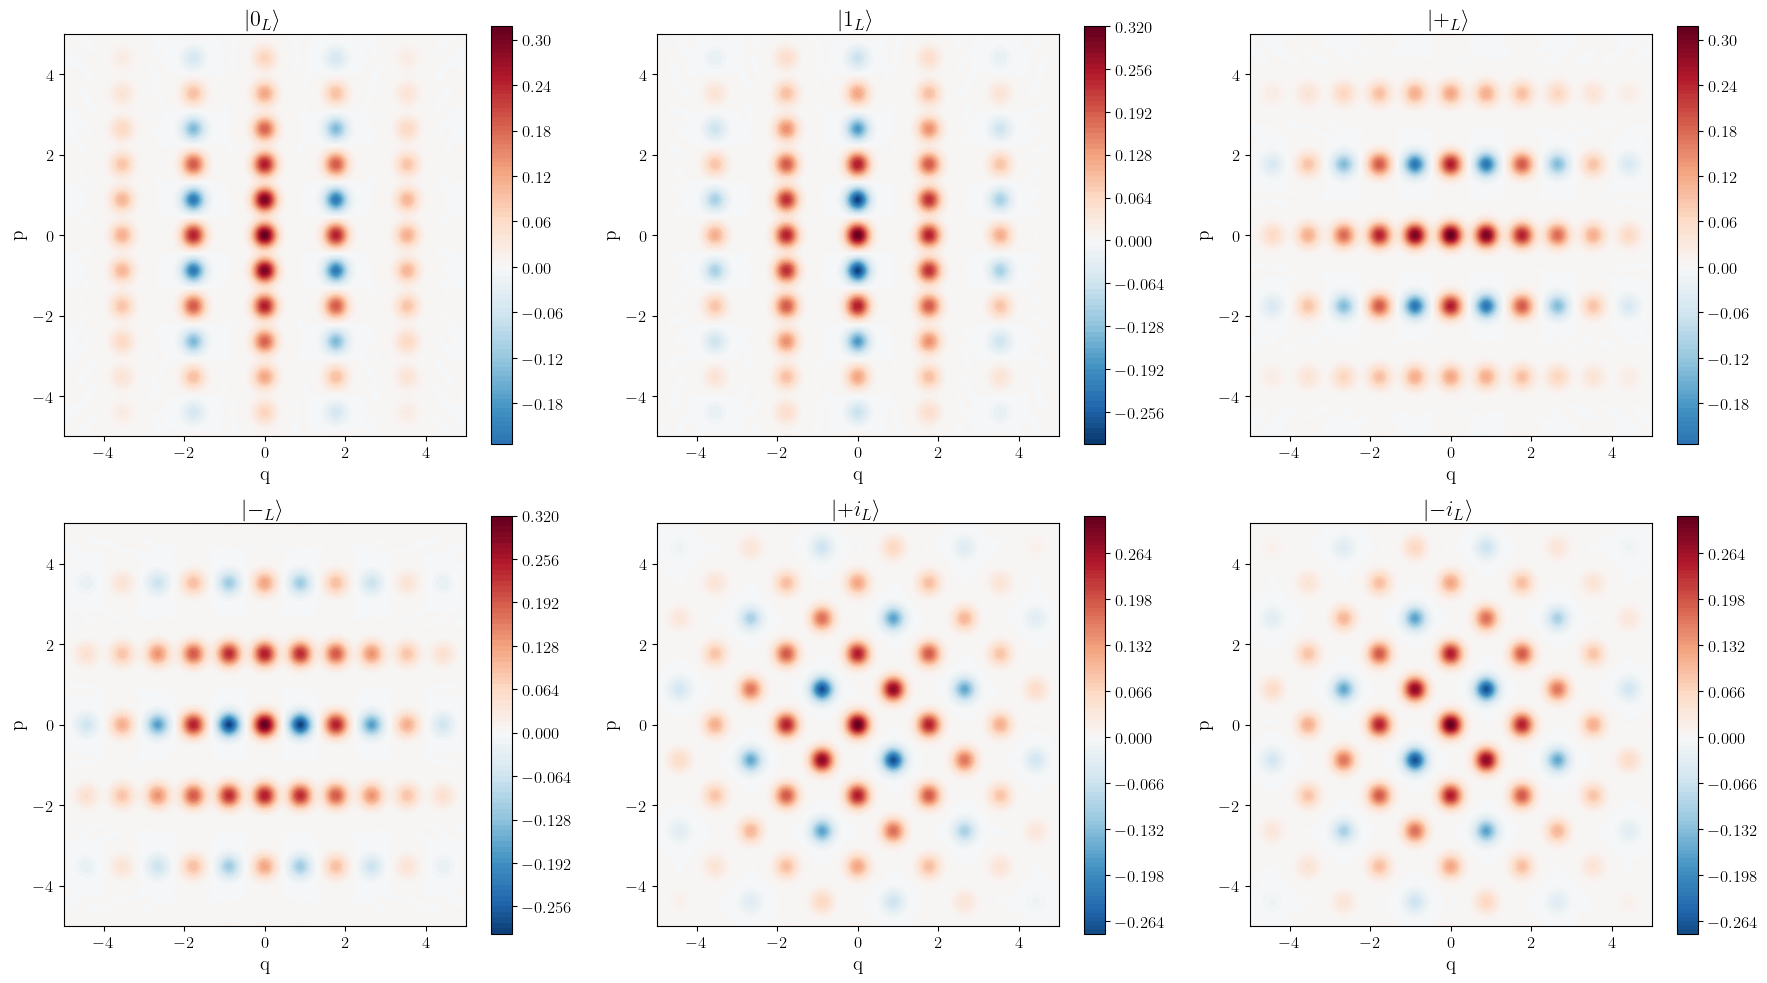

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (label, (_, result)) in zip(axes.flat, trajectories.items()):
    plot_wigner(
        result.states[-1],
        x_bound=x_bound,
        y_bound=y_bound,
        ax=ax,
        title=rf"$\ket{{{label}}}$",
    )

fig.tight_layout()
fig.savefig("../../figs/brachistochrone/brachistochrone_gkp_final_wigners.pdf", bbox_inches="tight")
plt.show()

## Photon-number distribution along a trajectory

For one representative target, track the Fock populations $P(n, t) = \bra{n} \rho(t) \ket{n}$ as the state evolves. The low-photon truncation boundary should remain unpopulated throughout, and the final distribution should match the target's native $P(n)$ (plotted alongside for reference).


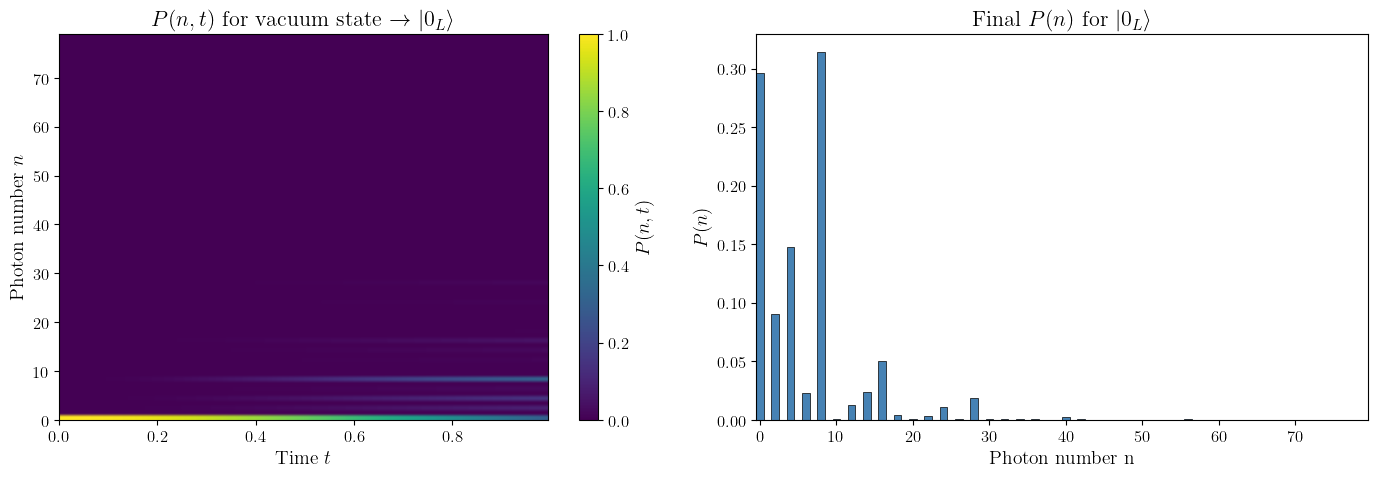

In [5]:
focus_label = r"0_L"
tlist, result = trajectories[focus_label]

populations = np.array(
    [np.real(qt.ket2dm(state).diag()) for state in result.states]
)  # shape (n_steps, n_fock)

fig, (ax_heatmap, ax_hist) = plt.subplots(1, 2, figsize=(14, 5))

im = ax_heatmap.imshow(
    populations.T,
    extent=(tlist[0], tlist[-1], 0, n_fock - 1),
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
fig.colorbar(im, ax=ax_heatmap, label=r"$P(n, t)$")
ax_heatmap.set_xlabel(r"Time $t$")
ax_heatmap.set_ylabel(r"Photon number $n$")
ax_heatmap.set_title(rf"$P(n, t)$ for vacuum state $\to$ $\ket{{{focus_label}}}$")

plot_photon_number(
    result.states[-1],
    ax=ax_hist,
    title=rf"Final $P(n)$ for $\ket{{{focus_label}}}$",
)

fig.tight_layout()
fig.savefig(f"../../figs/brachistochrone/brachistochrone_photon_distribution_{focus_label}.pdf", bbox_inches="tight")
plt.show()

## Structure of the optimal Hamiltonian

The brachistochrone construction produces $H$ of rank two in the $\{\ket{\psi_i}, \ket{\psi_f^\perp}\}$ subspace. In the Fock basis this shows up as a sparse matrix whose nonzero entries encode the coherent-state components of the target. The Hamiltonian is Hermitian, so we plot the real and imaginary parts on a symmetric diverging scale.


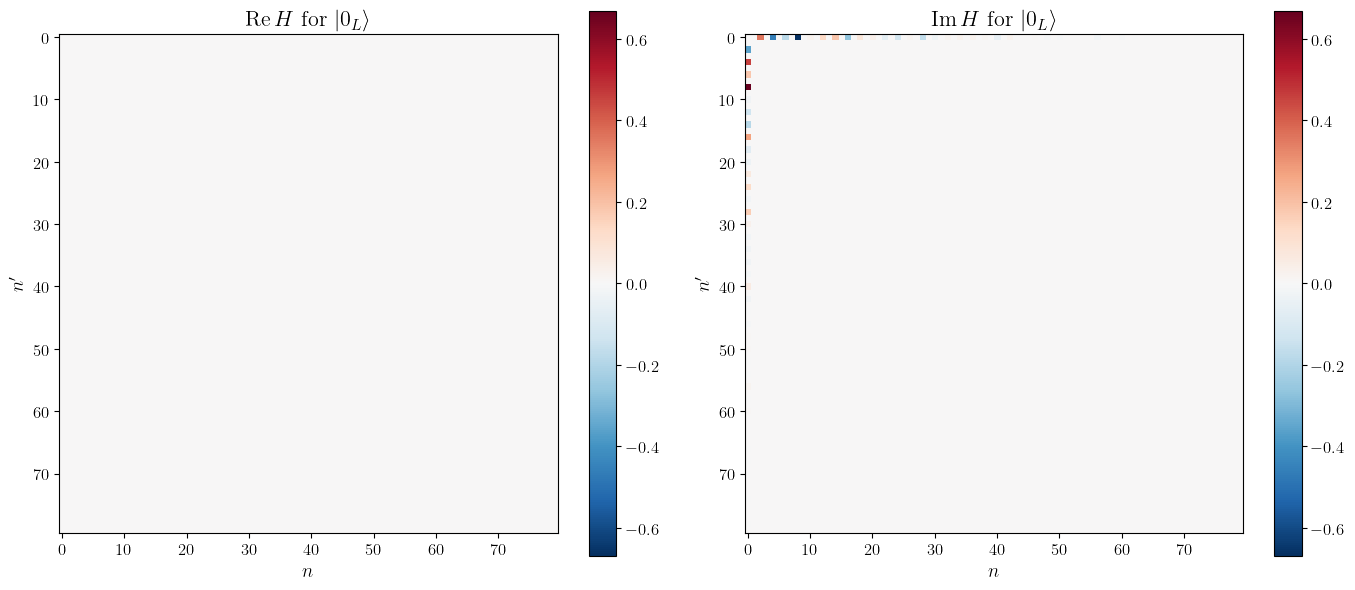

In [6]:
focus_label = r"0_L"
h = optimal_hamiltonians[focus_label].full()

vmax = float(np.max(np.abs(h)))
fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(14, 6))

im_re = ax_re.imshow(h.real, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax_re.set_title(rf"$\mathrm{{Re}}\, H$ for $\ket{{{focus_label}}}$")
ax_re.set_xlabel(r"$n$")
ax_re.set_ylabel(r"$n'$")
fig.colorbar(im_re, ax=ax_re)

im_im = ax_im.imshow(h.imag, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax_im.set_title(rf"$\mathrm{{Im}}\, H$ for $\ket{{{focus_label}}}$")
ax_im.set_xlabel(r"$n$")
ax_im.set_ylabel(r"$n'$")
fig.colorbar(im_im, ax=ax_im)

fig.tight_layout()
fig.savefig(f"../../figs/brachistochrone/brachistochrone_state_prep_hamiltonian_{focus_label}.pdf", bbox_inches="tight")
plt.show()

## Minimum evolution times

Summary of the Mandelstam-Tamm bound $T = \Omega_B / \lVert H \rVert$ for each cardinal target. States with larger Bures angle from the vacuum take longer to reach at fixed energy budget.


In [7]:
for label, t in min_times.items():
    print(f"  vac -> |{label}>: T = {t:.4f}")

  vac -> |0_L>: T = 0.9953
  vac -> |1_L>: T = 1.3471
  vac -> |+_L>: T = 0.9984
  vac -> |-_L>: T = 1.3408
  vac -> |+i_L>: T = 1.1422
  vac -> |-i_L>: T = 1.1422
